In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


# Get our dataset
Dataset Link: [10000 Restaurant Reviews](https://www.kaggle.com/datasets/joebeachcapital/restaurant-reviews)

In [2]:
import pandas as pd
df = pd.read_csv("/content/reviews.csv")
df.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,7514
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0,2447.0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0,NaN
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0,NaN
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0,NaN
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0,NaN


# Understand and prepare the data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Restaurant  10000 non-null  object 
 1   Reviewer    9962 non-null   object 
 2   Review      9955 non-null   object 
 3   Rating      9962 non-null   object 
 4   Metadata    9962 non-null   object 
 5   Time        9962 non-null   object 
 6   Pictures    10000 non-null  int64  
 7   7514        1 non-null      float64
dtypes: float64(1), int64(1), object(6)
memory usage: 625.1+ KB


In [4]:
df[["Restaurant", "Review", "Rating"]].head(10)

,Restaurant,Review,Rating
0,Beyond Flavours,"The ambience was good, food was quite good . h...",5
1,Beyond Flavours,Ambience is too good for a pleasant evening. S...,5
2,Beyond Flavours,A must try.. great food great ambience. Thnx f...,5
3,Beyond Flavours,Soumen das and Arun was a great guy. Only beca...,5
4,Beyond Flavours,Food is good.we ordered Kodi drumsticks and ba...,5
5,Beyond Flavours,"Ambiance is good, service is good, food is aPr...",5
6,Beyond Flavours,"Its a very nice place, ambience is different, ...",5
7,Beyond Flavours,Well after reading so many reviews finally vis...,4
8,Beyond Flavours,"Excellent food , specially if you like spicy f...",5
9,Beyond Flavours,Came for the birthday treat of a close friend....,5


In [5]:
df[["Restaurant", "Review", "Rating"]].tail(10)

,Restaurant,Review,Rating
9990,Chinese Pavilion,Amazing food ! I always go here when I want Ch...,5
9991,Chinese Pavilion,I was never a fan of Chinese food until I visi...,5
9992,Chinese Pavilion,I visited this restaurant with friends and was...,5
9993,Chinese Pavilion,"Im going to cut to the chase, The food is exce...",5
9994,Chinese Pavilion,Chinese Pavilion in Banjara HIlls was the firs...,1.5
9995,Chinese Pavilion,Madhumathi Mahajan Well to start with nice cou...,3
9996,Chinese Pavilion,This place has never disappointed us.. The foo...,4.5
9997,Chinese Pavilion,"Bad rating is mainly because of ""Chicken Bone ...",1.5
9998,Chinese Pavilion,I personally love and prefer Chinese Food. Had...,4
9999,Chinese Pavilion,Checked in here to try some delicious chinese ...,3.5


# Create sentiment labels

In [6]:
df["Rating"].value_counts(dropna=False).sort_index()

,count
Rating,
1,1735
1.5,9
2,684
2.5,19
3,1193
3.5,47
4,2373
4.5,69
5,3832


In [7]:
print("Pictures:")
print(df["Pictures"].value_counts().head())

print("\n7514:")
print(df["7514"].value_counts(dropna=False))

Pictures:
Pictures
0    8016
1     707
2     383
3     246
4     129
Name: count, dtype: int64

7514:
7514
NaN       9999
2447.0       1
Name: count, dtype: int64


# Clean the dataset

In [8]:
# Remove rows without a review or rating
df = df.dropna(subset=["Review", "Rating"]).copy()

# Convert Rating to numeric
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

# Remove ratings that couldn't be converted (e.g. "Like")
df = df.dropna(subset=["Rating"]).copy()

# Create sentiment labels
def get_sentiment(rating):
    if rating < 3:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

df["Sentiment"] = df["Rating"].apply(get_sentiment)

# Keep only the columns we actually need
df = df[["Review", "Rating", "Sentiment"]]

# Reset the index
df = df.reset_index(drop=True)

df.head()

,Review,Rating,Sentiment
0,"The ambience was good, food was quite good . h...",5.0,Positive
1,Ambience is too good for a pleasant evening. S...,5.0,Positive
2,A must try.. great food great ambience. Thnx f...,5.0,Positive
3,Soumen das and Arun was a great guy. Only beca...,5.0,Positive
4,Food is good.we ordered Kodi drumsticks and ba...,5.0,Positive


In [9]:
df.tail()

,Review,Rating,Sentiment
9949,Madhumathi Mahajan Well to start with nice cou...,3.0,Neutral
9950,This place has never disappointed us.. The foo...,4.5,Positive
9951,"Bad rating is mainly because of ""Chicken Bone ...",1.5,Negative
9952,I personally love and prefer Chinese Food. Had...,4.0,Positive
9953,Checked in here to try some delicious chinese ...,3.5,Positive


In [10]:
print("Number of reviews:", len(df))

print("\nSentiment distribution:")
print(df["Sentiment"].value_counts())

print("\nPercentages:")
print(df["Sentiment"].value_counts(normalize=True) * 100)

Number of reviews: 9954

Sentiment distribution:
Sentiment
Positive    6315
Negative    2447
Neutral     1192
Name: count, dtype: int64

Percentages:
Sentiment
Positive    63.441832
Negative    24.583082
Neutral     11.975085
Name: proportion, dtype: float64


In [11]:
for sentiment in ["Negative", "Neutral", "Positive"]:
    print(f"\n--- {sentiment} ---")
    print(df[df["Sentiment"] == sentiment][["Review", "Rating"]].sample(3, random_state=42))


--- Negative ---
                                                 Review  Rating
8916                                Less meat provided.     1.0
5112  I had ordered a Veg Biriyani today, 1st time I...     1.0
4901  Very rude staff and bad service. Disapppinted....     1.0

--- Neutral ---
                                                 Review  Rating
7629  I personally liked the bagel with cheese and c...     3.0
2514  Good place to go around\nAmbience is good and ...     3.0
2608  I went here to celebrate my birthday.....\nIf ...     3.0

--- Positive ---
                                                 Review  Rating
1728  Best food is here just like a home food. I sug...     5.0
6082  Amazing dj night. Very cooperative and friendl...     5.0
7635  I am from Chennai and a big fan for old Madras...     4.0


## Split the dataset

### Install the libraries

In [12]:
!pip install -q transformers datasets accelerate scikit-learn

In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

### Create the first split
- train_df → 80%
- val_df   → 10%
- test_df  → 10%

In [14]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["Sentiment"],
    random_state=42
)

In [15]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["Sentiment"],
    random_state=42
)

### Check the sizes

In [16]:
print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Training: 7963
Validation: 995
Test: 996


### Check class distribution

In [17]:
print("Training distribution:")
print(train_df["Sentiment"].value_counts(normalize=True))

print("\nValidation distribution:")
print(val_df["Sentiment"].value_counts(normalize=True))

print("\nTest distribution:")
print(test_df["Sentiment"].value_counts(normalize=True))

Training distribution:
Sentiment
Positive    0.634434
Negative    0.245762
Neutral     0.119804
Name: proportion, dtype: float64

Validation distribution:
Sentiment
Positive    0.634171
Negative    0.246231
Neutral     0.119598
Name: proportion, dtype: float64

Test distribution:
Sentiment
Positive    0.634538
Negative    0.245984
Neutral     0.119478
Name: proportion, dtype: float64


## Convert sentiment into numbers
- Negative → 0
- Neutral  → 1
- Positive → 2

In [18]:
# create mapping
label2id = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
}

id2label = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

In [19]:
for dataset in [train_df, val_df, test_df]:
    dataset["label"] = dataset["Sentiment"].map(label2id)

In [20]:
train_df.head()

,Review,Rating,Sentiment,label
75,I have been at this place for dinner a few day...,2.0,Negative,0
1717,Nice food good place for foodies and tasty is ...,5.0,Positive,2
8550,Good,5.0,Positive,2
5806,Drinks(4.5/5)- I think Tempteys and MOM rule t...,4.0,Positive,2
9541,I was passing by that road and was instantly c...,4.0,Positive,2


## Convert our Pandas DataFrames to Hugging Face datasets
BERT's training tools work nicely with Hugging Face's `Dataset` format.

In [21]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["Review", "label"]],
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df[["Review", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["Review", "label"]],
    preserve_index=False
)

In [22]:
print(train_dataset)

Dataset({
    features: ['Review', 'label'],
    num_rows: 7963
})


# Tokenization
"The food was amazing!" → BERT Tokenizer → ["[CLS]", "the", "food", "was", "amazing", "!", "[SEP]"] → [101, 1996, 2833, 2001, 6429, 999, 102]

## Load BERT's tokenizer
I'm going to use `bert-base-uncased`.

In [23]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# See what the tokenizer actually does

In [24]:
text = train_df.iloc[0]["Review"]
print(text)

I have been at this place for dinner a few days back. The ambience was good. The restaurant was almost half occupied. We immediately got a table. But then waited for 10 mins to get water and menu, that too after a few reminders. We ordered a few starters, main course items and mock drinks. Only the starters could be served in 30 mins. There was no sign of mock drinks! We noticed similar service issues on other tables. Noticed guests literally shouting on the staff.

The food was just average. Dishes were not prepared well, at least when compared to 4.1 rating on Zomato.

We finally decided to just have starters, and hop onto another restaurant for rest of the meal!


In [25]:
tokens = tokenizer.tokenize(text)
print(tokens)

['i', 'have', 'been', 'at', 'this', 'place', 'for', 'dinner', 'a', 'few', 'days', 'back', '.', 'the', 'am', '##bie', '##nce', 'was', 'good', '.', 'the', 'restaurant', 'was', 'almost', 'half', 'occupied', '.', 'we', 'immediately', 'got', 'a', 'table', '.', 'but', 'then', 'waited', 'for', '10', 'min', '##s', 'to', 'get', 'water', 'and', 'menu', ',', 'that', 'too', 'after', 'a', 'few', 'reminder', '##s', '.', 'we', 'ordered', 'a', 'few', 'starters', ',', 'main', 'course', 'items', 'and', 'mock', 'drinks', '.', 'only', 'the', 'starters', 'could', 'be', 'served', 'in', '30', 'min', '##s', '.', 'there', 'was', 'no', 'sign', 'of', 'mock', 'drinks', '!', 'we', 'noticed', 'similar', 'service', 'issues', 'on', 'other', 'tables', '.', 'noticed', 'guests', 'literally', 'shouting', 'on', 'the', 'staff', '.', 'the', 'food', 'was', 'just', 'average', '.', 'dishes', 'were', 'not', 'prepared', 'well', ',', 'at', 'least', 'when', 'compared', 'to', '4', '.', '1', 'rating', 'on', 'z', '##oma', '##to', '.'

# Convert tokens to IDs

In [26]:
encoded = tokenizer(text)
print(encoded)

{'input_ids': [101, 1045, 2031, 2042, 2012, 2023, 2173, 2005, 4596, 1037, 2261, 2420, 2067, 1012, 1996, 2572, 11283, 5897, 2001, 2204, 1012, 1996, 4825, 2001, 2471, 2431, 4548, 1012, 2057, 3202, 2288, 1037, 2795, 1012, 2021, 2059, 4741, 2005, 2184, 8117, 2015, 2000, 2131, 2300, 1998, 12183, 1010, 2008, 2205, 2044, 1037, 2261, 14764, 2015, 1012, 2057, 3641, 1037, 2261, 29400, 1010, 2364, 2607, 5167, 1998, 12934, 8974, 1012, 2069, 1996, 29400, 2071, 2022, 2366, 1999, 2382, 8117, 2015, 1012, 2045, 2001, 2053, 3696, 1997, 12934, 8974, 999, 2057, 4384, 2714, 2326, 3314, 2006, 2060, 7251, 1012, 4384, 6368, 6719, 11273, 2006, 1996, 3095, 1012, 1996, 2833, 2001, 2074, 2779, 1012, 10447, 2020, 2025, 4810, 2092, 1010, 2012, 2560, 2043, 4102, 2000, 1018, 1012, 1015, 5790, 2006, 1062, 9626, 3406, 1012, 2057, 2633, 2787, 2000, 2074, 2031, 29400, 1010, 1998, 6154, 3031, 2178, 4825, 2005, 2717, 1997, 1996, 7954, 999, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

- `input_ids`: The actual numerical representation of the tokens.
- `attention_mask`: Tells BERT which positions contain actual text and which are padding.
- `token_type_ids`: Used by BERT to distinguish between two different sentences when doing tasks involving sentence pairs.

### Set the maximum sequence length
`max_length = 128`

# Tokenize the entire dataset

In [27]:
def tokenize_function(examples):
    return tokenizer(
        examples["Review"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [28]:
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_val = val_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/7963 [00:00<?, ? examples/s]

Map:   0%|          | 0/995 [00:00<?, ? examples/s]

Map:   0%|          | 0/996 [00:00<?, ? examples/s]

# Inspect results

In [29]:
print(tokenized_train)

Dataset({
    features: ['Review', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 7963
})


In [30]:
tokenized_train[0]

{'Review': 'I have been at this place for dinner a few days back. The ambience was good. The restaurant was almost half occupied. We immediately got a table. But then waited for 10 mins to get water and menu, that too after a few reminders. We ordered a few starters, main course items and mock drinks. Only the starters could be served in 30 mins. There was no sign of mock drinks! We noticed similar service issues on other tables. Noticed guests literally shouting on the staff.\n\nThe food was just average. Dishes were not prepared well, at least when compared to 4.1 rating on Zomato.\n\nWe finally decided to just have starters, and hop onto another restaurant for rest of the meal!',
 'label': 0,
 'input_ids': [101,
  1045,
  2031,
  2042,
  2012,
  2023,
  2173,
  2005,
  4596,
  1037,
  2261,
  2420,
  2067,
  1012,
  1996,
  2572,
  11283,
  5897,
  2001,
  2204,
  1012,
  1996,
  4825,
  2001,
  2471,
  2431,
  4548,
  1012,
  2057,
  3202,
  2288,
  1037,
  2795,
  1012,
  2021,
  

# Load pretrained BERT

In [31]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Check model

In [32]:
print(model)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [33]:
total_params = sum(p.numel() for p in model.parameters())

print(f"Total parameters: {total_params:,}")

Total parameters: 109,484,547


In [34]:
tokenized_train = tokenized_train.remove_columns(["Review"])
tokenized_val = tokenized_val.remove_columns(["Review"])
tokenized_test = tokenized_test.remove_columns(["Review"])

In [35]:
print(tokenized_train)

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 7963
})


In [37]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="weighted")
    macro_f1 = f1_score(labels, predictions, average="macro")

    return {
        "accuracy": accuracy,
        "f1": f1,
        "macro_f1": macro_f1
    }

In [38]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./bert-restaurant-sentiment",

    num_train_epochs=3,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    learning_rate=2e-5,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",

    logging_steps=50,

    report_to="none"
)

# Create Trainer

In [39]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics
)

In [40]:
import torch

print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
Tesla T4


In [41]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Macro F1
1,0.320138,0.330190,0.876382,0.862986,0.748179
2,0.274779,0.396246,0.862312,0.854562,0.737537
3,0.177036,0.446583,0.863317,0.858246,0.742160


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=1494, training_loss=0.29928937526432225, metrics={'train_runtime': 636.2137, 'train_samples_per_second': 37.549, 'train_steps_per_second': 2.348, 'total_flos': 1571379109026048.0, 'train_loss': 0.29928937526432225, 'epoch': 3.0})

In [43]:
test_results = trainer.evaluate(tokenized_test)

print(test_results)

Training Loss,Validation Loss,Epoch,Accuracy,F1,Macro F1
0.177036,0.352767,3,0.866466,0.848957,0.717952


{'eval_loss': 0.3527671992778778, 'eval_accuracy': 0.8664658634538153, 'eval_f1': 0.8489567900887036, 'eval_macro_f1': 0.7179515013667}


In [44]:
predictions = trainer.predict(tokenized_test)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

In [45]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Negative", "Neutral", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.81      0.88      0.84       245
     Neutral       0.59      0.27      0.37       119
    Positive       0.91      0.97      0.94       632

    accuracy                           0.87       996
   macro avg       0.77      0.71      0.72       996
weighted avg       0.85      0.87      0.85       996



# Confusion Matrix

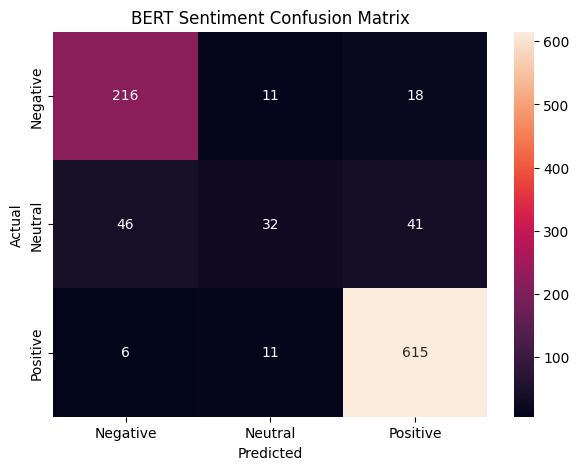

In [46]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BERT Sentiment Confusion Matrix")
plt.show()

# Save the trained model

In [47]:
model_path = "./restaurant_reviews_sentiment_bert"

trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)

print(f"Model saved to: {model_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: ./restaurant_reviews_sentiment_bert


# Test the saved model manually

In [48]:
import torch

def predict_sentiment(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {key: value.to(model.device) for key, value in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(outputs.logits, dim=-1)
    prediction = torch.argmax(probabilities, dim=-1).item()

    return id2label[prediction], probabilities[0].cpu().numpy()

In [49]:
review = "The food was amazing and the staff were very friendly!"

sentiment, probabilities = predict_sentiment(review)

print("Sentiment:", sentiment)
print("Probabilities:", probabilities)

Sentiment: Positive
Probabilities: [0.00140818 0.00709464 0.9914971 ]


In [50]:
test_reviews = [
    "The food was amazing and the staff were very friendly!",
    "Terrible food and extremely rude service.",
    "The food was okay. Nothing special, but not bad either."
]

for review in test_reviews:
    sentiment, probabilities = predict_sentiment(review)
    print(f"\nReview: {review}")
    print(f"Prediction: {sentiment}")
    print(f"Probabilities: {probabilities}")


Review: The food was amazing and the staff were very friendly!
Prediction: Positive
Probabilities: [0.00140818 0.00709464 0.9914971 ]

Review: Terrible food and extremely rude service.
Prediction: Negative
Probabilities: [0.97076845 0.0236703  0.00556129]

Review: The food was okay. Nothing special, but not bad either.
Prediction: Neutral
Probabilities: [0.24119389 0.65808624 0.10071986]


In [51]:
review = "there was a jaw-dropping show at the restaurant"

sentiment, probabilities = predict_sentiment(review)

print("Sentiment:", sentiment)
print("Probabilities:", probabilities)

Sentiment: Positive
Probabilities: [0.29774228 0.13953853 0.56271917]
